# Money as a Medium of Exchange in an Economy with Artificially Intelligent Agents

## Replicating Marimon, McGrattan, and Sargent (1990)

This notebook replicates the key computational experiments from:

> Marimon, R., McGrattan, E., & Sargent, T. J. (1990). "Money as a Medium of Exchange in an Economy with Artificially Intelligent Agents." *Journal of Economic Dynamics and Control*, 14, 329-373.

### Overview

Marimon, McGrattan, and Sargent studied the exchange economies of [Kiyotaki and Wright (1989)](https://doi.org/10.1086/261634) in which agents must use a commodity or fiat money as a medium of exchange if trade is to occur. While Kiyotaki and Wright studied *rational* agents playing Nash-Markov equilibria, Marimon, McGrattan, and Sargent replaced rational agents with **artificially intelligent** agents that use John Holland's **classifier systems** to learn decision rules.

The key questions addressed are:
1. Can artificially intelligent Holland agents **learn** to play Nash equilibrium strategies?
2. When multiple equilibria exist ("fundamental" vs. "speculative"), which equilibrium **emerges**?
3. Can classifier systems handle more complex economies, including **fiat money**?

### Holland's Classifier System

A **classifier system** is a collection of if-then rules (classifiers), each encoded as a string in a trinary alphabet $\{0, 1, \#\}$, where $\#$ means "don't care." Each classifier has:
- A **condition** part: specifies which states activate the rule
- An **action** part: specifies the decision to take (e.g., trade or don't trade)
- A **strength**: a running average of past net rewards, used to select among competing rules

The system selects the highest-strength matching rule via an **auction mechanism**, and updates strengths via a **bucket brigade** payment system. A **genetic algorithm** periodically introduces new rules by combining successful existing ones.

## 1. The Kiyotaki-Wright Environment

There are three types of agents indexed by $i = 1, 2, 3$. Each type $i$ agent:
- Gets utility only from consuming good $i$
- Has technology to produce good $i^*$ (where $i^* \neq i$)
- Can store only one unit of one good at a time

**Model A production structure** (a "Wicksell triangle" — no double coincidence of wants):

| Type $i$ | Produces $i^*$ | Consumes |
|----------|---------------|----------|
| 1        | 2             | 1        |
| 2        | 3             | 2        |
| 3        | 1             | 3        |

**Storage costs** satisfy $s_3 > s_2 > s_1 > 0$, so good 1 is cheapest to store.

Each period:
1. Agents are randomly matched into pairs
2. Each agent decides whether to **propose a trade** (trade occurs only if both agree)
3. Each agent decides whether to **consume** the good they hold (if they consume good $i$, they get utility $u_i$ and immediately produce good $i^*$)

### Equilibria

- **Fundamental equilibrium**: Good 1 (lowest storage cost) serves as the general medium of exchange. Type II agents accept good 1 even though they don't consume it, using it to trade for good 2.
- **Speculative equilibrium**: Type I agents "speculate" by accepting good 3 (high storage cost) because they expect to easily trade it for good 1. This equilibrium can exist when $u_1$ is sufficiently large relative to $s_3 - s_2$.

## 2. Implementation

We now implement the classifier system simulation. The implementation is self-contained — all code needed to replicate the paper's results is in this notebook.

### 2.1 Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Setup complete.")

Setup complete.


### 2.2 Economy Configuration

We define a configuration class that specifies all the parameters of the Kiyotaki-Wright economy and the classifier system.

In [2]:
@dataclass
class EconomyConfig:
    """
    Configuration for a Kiyotaki-Wright economy with classifier system agents.
    
    Parameters
    ----------
    n_types : int
        Number of agent types (and goods).
    n_agents_per_type : int  
        Number of agents of each type.
    produces : np.ndarray
        produces[i] = good produced by type i after consumption (0-indexed).
    storage_costs : np.ndarray
        storage_costs[k] = per-period cost of storing good k.
    utility : np.ndarray
        utility[i] = utility type i gets from consuming good i.
    n_trade_classifiers : int
        Number of trade classifiers per agent type.
    n_consume_classifiers : int
        Number of consume classifiers per agent type.
    bid_trade : tuple
        (b11, b12) — bid constants for trade classifiers.
    bid_consume : tuple
        (b21, b22) — bid constants for consume classifiers.
    use_complete_enumeration : bool
        If True, start with all possible classifiers (complete enumeration).
    use_genetic_algorithm : bool
        If True, periodically apply the genetic algorithm.
    ga_frequency : float
        Base frequency for GA application (decreases as 1/sqrt(t)).
    """
    name: str = "Economy A1"
    n_types: int = 3
    n_agents_per_type: int = 50
    produces: np.ndarray = field(default_factory=lambda: np.array([1, 2, 0]))  # 0-indexed
    storage_costs: np.ndarray = field(default_factory=lambda: np.array([0.1, 1.0, 20.0]))
    utility: np.ndarray = field(default_factory=lambda: np.array([100.0, 100.0, 100.0]))
    n_trade_classifiers: int = 72
    n_consume_classifiers: int = 12
    bid_trade: tuple = (0.025, 0.025)
    bid_consume: tuple = (0.25, 0.25)
    use_complete_enumeration: bool = True
    use_genetic_algorithm: bool = False
    ga_frequency: float = 0.5
    ga_pcross: float = 0.6
    ga_pmutation: float = 0.01
    
    @property
    def n_agents(self):
        return self.n_types * self.n_agents_per_type
    
    @property 
    def n_goods(self):
        return self.n_types  # One good per type in the basic model

print("EconomyConfig class defined.")

EconomyConfig class defined.


### 2.3 The Classifier System

Each classifier is a trinary string encoding a (condition, action) pair. For the **trade** classifier with 3 goods:
- Condition: (own good, partner's good) — each encoded in 2 bits using $\{0, 1, \#\}$
- Action: 1 = propose trade, 0 = refuse

The encoding for goods is:

| Code | Good |
|------|------|
| 1 0  | Good 1 |
| 0 1  | Good 2 |
| 0 0  | Good 3 |
| 0 #  | Not good 1 |
| # 0  | Not good 2 |
| # #  | Any good |

With 6 possible conditions for own good × 6 for partner's good × 2 actions = **72** possible classifiers for the trade decision. For the consumption decision, there are 6 conditions × 2 actions = **12** possible classifiers.

#### Strength Update Rules

Strengths evolve as cumulative averages of net rewards (a key innovation of this paper):

$$S_{c,\tau+1} = S_{c,\tau} - \frac{1}{\tau}\left[(1 + b_2(c))S_{c,\tau} - \sum_e I_e b_1(e) S_{e,\tau} - U(\gamma)\right]$$

$$S_{e,\tau+1} = S_{e,\tau} - \frac{1}{\tau}\left[(1 + b_1(e))S_{e,\tau} - \sum_c I_c b_2(c) S_{c,\tau}\right]$$

where $U(\gamma)$ is the external payoff from consumption.

In [3]:
class Classifier:
    """
    A single classifier (if-then rule) in the classifier system.
    
    Attributes
    ----------
    condition : np.ndarray
        Condition part (trinary: 0, 1, or -1 for #).
    action : int
        Action part (0 or 1).
    strength : float
        Running average of net rewards.
    n_used : int
        Number of times this classifier has won the auction.
    """
    def __init__(self, condition: np.ndarray, action: int, strength: float = 0.0):
        self.condition = condition.copy()
        self.action = action
        self.strength = strength
        self.n_used = 1  # Initialize counter at 1 (as in the paper)
    
    def matches(self, state: np.ndarray) -> bool:
        """Check if this classifier's condition matches the given state."""
        for c, s in zip(self.condition, state):
            if c != -1 and c != s:  # -1 is the wildcard (#)
                return False
        return True
    
    @property
    def specificity(self) -> float:
        """Fraction inversely related to number of wildcards."""
        n_wildcards = np.sum(self.condition == -1)
        return 1.0 / (1.0 + n_wildcards)
    
    def bid(self, b1: float, b2: float) -> float:
        """Compute bid = (b1 + b2 * specificity) * strength."""
        return (b1 + b2 * self.specificity) * self.strength
    
    def __repr__(self):
        cond_str = ''.join(['#' if c == -1 else str(int(c)) for c in self.condition])
        return f"Classifier({cond_str} -> {self.action}, S={self.strength:.2f}, n={self.n_used})"


def encode_good(good_idx: int, n_goods: int) -> np.ndarray:
    """
    Encode a good index into binary representation.
    
    For 3 goods with 2-bit encoding:
        Good 0 -> [1, 0]
        Good 1 -> [0, 1]
        Good 2 -> [0, 0]
    """
    if n_goods == 3:
        encodings = np.array([[1, 0], [0, 1], [0, 0]])
    elif n_goods == 4:
        # For fiat money economy: goods 0-2 as before, good 3 (fiat) = [1, 1]
        encodings = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
    elif n_goods == 5:
        encodings = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 0], [1, 0, 1]])
    else:
        # General binary encoding
        n_bits = int(np.ceil(np.log2(max(n_goods, 2))))
        encodings = np.array([list(map(int, format(i, f'0{n_bits}b'))) for i in range(n_goods)])
    return encodings[good_idx]


def decode_good(encoding: np.ndarray, n_goods: int) -> int:
    """Decode a binary encoding back to a good index."""
    for i in range(n_goods):
        if np.array_equal(encoding, encode_good(i, n_goods)):
            return i
    return -1


def generate_all_conditions(n_bits: int) -> List[np.ndarray]:
    """
    Generate all possible conditions in the trinary alphabet {0, 1, #}.
    
    For 2-bit encoding of goods: {(1,0), (0,1), (0,0), (0,#), (#,0), (#,#)}
    These represent the 6 possible conditions per good position.
    """
    if n_bits == 2:
        # The 6 meaningful conditions for 3-good encoding
        return [
            np.array([1, 0]),   # Good 0
            np.array([0, 1]),   # Good 1
            np.array([0, 0]),   # Good 2
            np.array([0, -1]),  # Not good 0 (good 1 or 2)
            np.array([-1, 0]), # Not good 1 (good 0 or 2)
            np.array([-1, -1]) # Any good (wildcard)
        ]
    elif n_bits == 3:
        # For 5-good encoding with 3 bits
        conditions = []
        for b0 in [-1, 0, 1]:
            for b1 in [-1, 0, 1]:
                for b2 in [-1, 0, 1]:
                    conditions.append(np.array([b0, b1, b2]))
        return conditions
    else:
        raise ValueError(f"n_bits={n_bits} not supported")


def create_complete_classifier_set(n_goods: int, classifier_type: str) -> List[Classifier]:
    """
    Create a complete enumeration of all possible classifiers.
    
    Parameters
    ----------
    n_goods : int
        Number of goods in the economy.
    classifier_type : str
        'trade' or 'consume'.
        
    Returns
    -------
    list of Classifier
        Complete set of classifiers with initial strength 0.
    """
    if n_goods <= 3:
        n_bits = 2
    elif n_goods <= 5:
        n_bits = 3
    else:
        n_bits = int(np.ceil(np.log2(n_goods)))
    
    own_conditions = generate_all_conditions(n_bits)
    
    classifiers = []
    if classifier_type == 'trade':
        partner_conditions = generate_all_conditions(n_bits)
        for own in own_conditions:
            for partner in partner_conditions:
                condition = np.concatenate([own, partner])
                for action in [0, 1]:
                    classifiers.append(Classifier(condition, action, strength=0.0))
    elif classifier_type == 'consume':
        for own in own_conditions:
            for action in [0, 1]:
                classifiers.append(Classifier(own, action, strength=0.0))
    
    return classifiers


def create_random_classifier_set(n_classifiers: int, cond_length: int,
                                  initial_strength: float = 0.0) -> List[Classifier]:
    """
    Create a random set of classifiers (incomplete enumeration).
    
    Each bit in the condition is drawn from {-1, 0, 1} with equal probability.
    """
    classifiers = []
    for _ in range(n_classifiers):
        condition = np.random.choice([-1, 0, 1], size=cond_length).astype(float)
        action = np.random.randint(0, 2)
        classifiers.append(Classifier(condition, action, strength=initial_strength))
    return classifiers


# Quick test
trade_classifiers = create_complete_classifier_set(3, 'trade')
consume_classifiers = create_complete_classifier_set(3, 'consume')
print(f"Trade classifiers (complete enumeration): {len(trade_classifiers)}")
print(f"Consume classifiers (complete enumeration): {len(consume_classifiers)}")
print(f"\nExample trade classifier: {trade_classifiers[0]}")
print(f"Example consume classifier: {consume_classifiers[0]}")

Trade classifiers (complete enumeration): 72
Consume classifiers (complete enumeration): 12

Example trade classifier: Classifier(1010 -> 0, S=0.00, n=1)
Example consume classifier: Classifier(10 -> 0, S=0.00, n=1)


### 2.4 The Classifier System Agent

Each agent type uses two interconnected classifier systems:
1. **Trade classifier**: Maps pre-trade state $(x_a, x_{\rho(a)})$ → trade decision $\lambda$
2. **Consume classifier**: Maps post-trade holdings $x_a^+$ → consume decision $\gamma$

The **auction** selects the highest-strength matching classifier, and the **bucket brigade** passes payments between winning classifiers.

In [4]:
class ClassifierAgent:
    """
    An agent type using classifier systems for trade and consumption decisions.
    
    All agents of the same type share classifier systems (as in the paper,
    to economize on computation).
    
    Parameters
    ----------
    type_id : int
        Agent type (0-indexed).
    config : EconomyConfig
        Economy configuration.
    """
    def __init__(self, type_id: int, config: EconomyConfig):
        self.type_id = type_id
        self.config = config
        self.n_goods = config.n_goods
        
        if self.n_goods <= 3:
            self.n_bits = 2
        elif self.n_goods <= 5:
            self.n_bits = 3
        else:
            self.n_bits = int(np.ceil(np.log2(self.n_goods)))
        
        # Initialize classifier systems
        if config.use_complete_enumeration:
            self.trade_classifiers = create_complete_classifier_set(self.n_goods, 'trade')
            self.consume_classifiers = create_complete_classifier_set(self.n_goods, 'consume')
        else:
            self.trade_classifiers = create_random_classifier_set(
                config.n_trade_classifiers, 2 * self.n_bits)
            self.consume_classifiers = create_random_classifier_set(
                config.n_consume_classifiers, self.n_bits)
        
        # Track last winning consume classifier (for bucket brigade)
        self.last_consume_winner = None
        self.last_consume_bid_frac = 0.0
    
    def get_trade_decision(self, own_good: int, partner_good: int) -> Tuple[int, int]:
        """
        Decide whether to propose a trade.
        
        Returns
        -------
        (action, winner_idx) : tuple
            action = 1 (trade) or 0 (don't trade), and index of winning classifier.
        """
        # Encode state
        own_enc = encode_good(own_good, self.n_goods)
        partner_enc = encode_good(partner_good, self.n_goods)
        state = np.concatenate([own_enc, partner_enc])
        
        # Find matching classifiers
        matches = [(i, c) for i, c in enumerate(self.trade_classifiers) if c.matches(state)]
        
        if not matches:
            # No matching classifier — create one (creation step)
            action = np.random.randint(0, 2)
            new_c = Classifier(state.copy(), action, strength=0.0)
            self.trade_classifiers.append(new_c)
            return action, len(self.trade_classifiers) - 1
        
        # Auction: highest strength wins
        best_idx, best_classifier = max(matches, key=lambda x: x[1].strength)
        return best_classifier.action, best_idx
    
    def get_consume_decision(self, holding: int) -> Tuple[int, int]:
        """
        Decide whether to consume the currently held good.
        
        Returns
        -------
        (action, winner_idx) : tuple
            action = 1 (consume) or 0 (don't consume), and index of winning classifier.
        """
        state = encode_good(holding, self.n_goods)
        matches = [(i, c) for i, c in enumerate(self.consume_classifiers) if c.matches(state)]
        
        if not matches:
            action = np.random.randint(0, 2)
            new_c = Classifier(state.copy(), action, strength=0.0)
            self.consume_classifiers.append(new_c)
            return action, len(self.consume_classifiers) - 1
        
        best_idx, best_classifier = max(matches, key=lambda x: x[1].strength)
        return best_classifier.action, best_idx
    
    def update_strengths(self, trade_winner_idx: int, consume_winner_idx: int,
                         external_payoff: float, trade_happened: bool):
        """
        Update classifier strengths using the bucket brigade algorithm.
        
        The bucket brigade connects trade and consumption classifiers:
        - The winning consume classifier at t pays the winning trade classifier at t
        - The winning trade classifier at t pays the winning consume classifier at t-1
        - External payoff flows to the winning consume classifier at t
        
        Parameters
        ----------
        trade_winner_idx : int
            Index of winning trade classifier.
        consume_winner_idx : int
            Index of winning consume classifier.
        external_payoff : float
            Net utility from consumption decision (can be negative for storage costs).
        trade_happened : bool
            Whether the trade actually occurred (both parties agreed).
        """
        b11, b12 = self.config.bid_trade
        b21, b22 = self.config.bid_consume
        
        e_cls = self.trade_classifiers[trade_winner_idx]
        c_cls = self.consume_classifiers[consume_winner_idx]
        
        # Compute bid fractions
        b1_e = b11 + b12 * e_cls.specificity
        b2_c = b21 + b22 * c_cls.specificity
        
        # Only update trade classifier if trade actually happened or was refused
        # (don't update if offer was not reciprocated and action was 'trade')
        if trade_happened or e_cls.action == 0:
            e_cls.n_used += 1
            tau_e = e_cls.n_used
            
            # Exchange classifier strength update (eq. 11 in paper)
            # Receives payment from consume classifier, pays previous consume classifier
            payment_from_consume = b2_c * c_cls.strength
            e_cls.strength = e_cls.strength - (1.0 / tau_e) * (
                (1 + b1_e) * e_cls.strength - payment_from_consume
            )
        
        # Update consume classifier strength (eq. 10 in paper)
        c_cls.n_used += 1
        tau_c = c_cls.n_used
        
        payment_from_exchange = b1_e * e_cls.strength if (trade_happened or e_cls.action == 0) else 0.0
        c_cls.strength = c_cls.strength - (1.0 / tau_c) * (
            (1 + b2_c) * c_cls.strength - payment_from_exchange - external_payoff
        )
        
        # Pay previous consume classifier from current trade classifier
        if self.last_consume_winner is not None:
            prev_c = self.consume_classifiers[self.last_consume_winner]
            tau_prev = prev_c.n_used
            payment = b1_e * e_cls.strength
            prev_c.strength = prev_c.strength + payment / max(tau_prev, 1)
        
        # Remember this consume classifier for next round's bucket brigade
        self.last_consume_winner = consume_winner_idx
        self.last_consume_bid_frac = b2_c


print("ClassifierAgent class defined.")

ClassifierAgent class defined.


### 2.5 The Genetic Algorithm

When using incomplete enumeration (random initial classifiers), the **genetic algorithm** periodically:
1. Selects "fit" classifiers as potential parents (weighted by strength)
2. Mates pairs via **two-point crossover with generalization** (disagreeing bits become $\#$)
3. Replaces weak classifiers with the children

Additionally, **diversification** ensures that for any matched state, both actions (trade/don't trade) are represented, and **specialization** converts wildcards to specific values.

In [5]:
def apply_genetic_algorithm(classifiers: List[Classifier], 
                            n_pairs: int = 4,
                            pcross: float = 0.6,
                            pmutation: float = 0.01) -> List[Classifier]:
    """
    Apply the genetic algorithm to evolve the classifier population.
    
    This implements the generalization step from Section 6 of the paper:
    1. Select fit classifiers as parents (proportional to strength)
    2. Two-point crossover with generalization (disagreements -> #)
    3. Mutation
    4. Replace weak classifiers
    
    Parameters
    ----------
    classifiers : list of Classifier
        Current population of classifiers.
    n_pairs : int
        Number of mating pairs.
    pcross : float
        Crossover probability.
    pmutation : float
        Per-bit mutation probability.
        
    Returns
    -------
    list of Classifier
        Updated classifier population.
    """
    if len(classifiers) < 4:
        return classifiers
    
    # Compute fitness for selection (shift strengths to be non-negative)
    strengths = np.array([c.strength for c in classifiers])
    min_s = strengths.min()
    fitness = strengths - min_s + 1e-6  # Ensure positive
    
    # Select parents (fitness-proportional)
    total_fitness = fitness.sum()
    probs = fitness / total_fitness
    
    n_classifiers = len(classifiers)
    cond_length = len(classifiers[0].condition)
    
    children = []
    for _ in range(n_pairs):
        # Select two parents
        parents = np.random.choice(n_classifiers, size=2, replace=False, p=probs)
        p1, p2 = classifiers[parents[0]], classifiers[parents[1]]
        
        if np.random.rand() < pcross:
            # Two-point crossover with generalization
            pt1, pt2 = sorted(np.random.randint(0, cond_length + 1, size=2))
            
            # Determine focus region (inside or outside the points)
            focus_inside = np.random.rand() < 0.5
            
            child1_cond = p1.condition.copy()
            child2_cond = p2.condition.copy()
            
            for j in range(cond_length):
                in_region = (pt1 <= j < pt2) if focus_inside else (j < pt1 or j >= pt2)
                if in_region:
                    # Generalization: disagreements become wildcard
                    if p1.condition[j] != p2.condition[j]:
                        child1_cond[j] = -1  # Wildcard
                        child2_cond[j] = -1
            
            # Inherit action from respective parents
            child1_action = p1.action
            child2_action = p2.action
        else:
            # No crossover — children are copies of parents
            child1_cond = p1.condition.copy()
            child2_cond = p2.condition.copy()
            child1_action = p1.action
            child2_action = p2.action
        
        # Mutation
        for j in range(cond_length):
            if np.random.rand() < pmutation:
                child1_cond[j] = np.random.choice([-1, 0, 1])
            if np.random.rand() < pmutation:
                child2_cond[j] = np.random.choice([-1, 0, 1])
        if np.random.rand() < pmutation:
            child1_action = 1 - child1_action
        if np.random.rand() < pmutation:
            child2_action = 1 - child2_action
        
        # Average parents' strengths
        avg_strength = (p1.strength + p2.strength) / 2.0
        children.append(Classifier(child1_cond, child1_action, avg_strength))
        children.append(Classifier(child2_cond, child2_action, avg_strength))
    
    # Replace weakest classifiers
    # Sort by strength (ascending) and replace the weakest
    sorted_indices = np.argsort(strengths)
    for i, child in enumerate(children):
        if i < len(sorted_indices):
            classifiers[sorted_indices[i]] = child
    
    return classifiers


def apply_diversification(classifiers: List[Classifier], state: np.ndarray,
                          n_goods: int):
    """
    Ensure both actions are represented among matching classifiers.
    
    If all matching classifiers for a given state have the same action,
    create a new classifier with the opposite action.
    """
    matches = [(i, c) for i, c in enumerate(classifiers) if c.matches(state)]
    if not matches:
        return
    
    actions = [c.action for _, c in matches]
    if len(set(actions)) == 1:
        # All same action — create opposite
        opposite_action = 1 - actions[0]
        # Find weakest match to replace
        weakest_idx, weakest_c = min(matches, key=lambda x: x[1].strength)
        avg_strength = np.mean([c.strength for _, c in matches])
        classifiers[weakest_idx] = Classifier(state.copy(), opposite_action, avg_strength)


print("Genetic algorithm functions defined.")

Genetic algorithm functions defined.


### 2.6 The Simulation Engine

The simulation runs for $T$ periods. Each period:
1. All agents are randomly matched into pairs
2. For each pair, trade and consumption decisions are made using the classifier systems
3. Strengths are updated via the bucket brigade
4. (Optionally) the genetic algorithm is applied

We track the distribution of holdings $\pi_{it}^h(k)$ — the fraction of type $i$ agents holding good $k$ at time $t$ — which should converge to the equilibrium values.

In [6]:
class KiyotakiWrightSimulation:
    """
    Simulation of the Kiyotaki-Wright economy with classifier system agents.
    
    This class implements the full simulation as described in Section 7
    of Marimon, McGrattan, and Sargent (1990).
    """
    
    def __init__(self, config: EconomyConfig, seed: int = None):
        self.config = config
        if seed is not None:
            np.random.seed(seed)
        
        # Create agent types
        self.agents = [ClassifierAgent(i, config) for i in range(config.n_types)]
        
        # Initialize holdings: each agent starts with a random good
        self.holdings = np.random.randint(0, config.n_goods, size=config.n_agents)
        
        # Map agent index to type
        self.agent_types = np.repeat(np.arange(config.n_types), config.n_agents_per_type)
        
        # Statistics tracking
        self.history = {
            'holdings_dist': [],    # Holdings distribution over time
            'trade_rates': [],      # Trade rates per period
            'consumption_rates': [] # Consumption rates per period
        }
    
    def run(self, n_periods: int, record_every: int = 1, verbose: bool = True):
        """
        Run the simulation for n_periods.
        
        Parameters
        ----------
        n_periods : int
            Number of periods to simulate.
        record_every : int
            Record statistics every this many periods.
        verbose : bool
            Print progress updates.
        """
        config = self.config
        
        for t in range(1, n_periods + 1):
            trades_this_period = 0
            consumptions_this_period = 0
            
            # Random matching: create random permutation
            perm = np.random.permutation(config.n_agents)
            n_pairs = config.n_agents // 2
            
            for p in range(n_pairs):
                a1 = perm[2 * p]
                a2 = perm[2 * p + 1]
                
                type1 = self.agent_types[a1]
                type2 = self.agent_types[a2]
                good1 = self.holdings[a1]
                good2 = self.holdings[a2]
                
                agent1 = self.agents[type1]
                agent2 = self.agents[type2]
                
                # --- Trade Decision ---
                action1, trade_winner1 = agent1.get_trade_decision(good1, good2)
                action2, trade_winner2 = agent2.get_trade_decision(good2, good1)
                
                trade_happens = (action1 == 1) and (action2 == 1)
                
                if trade_happens:
                    # Swap goods
                    self.holdings[a1], self.holdings[a2] = good2, good1
                    trades_this_period += 1
                
                # Post-trade holdings
                post_good1 = self.holdings[a1]
                post_good2 = self.holdings[a2]
                
                # --- Consumption Decision ---
                cons_action1, cons_winner1 = agent1.get_consume_decision(post_good1)
                cons_action2, cons_winner2 = agent2.get_consume_decision(post_good2)
                
                # Process agent 1 consumption
                payoff1 = self._process_consumption(a1, type1, post_good1, cons_action1)
                if cons_action1 == 1 and post_good1 == type1:
                    consumptions_this_period += 1
                
                # Process agent 2 consumption
                payoff2 = self._process_consumption(a2, type2, post_good2, cons_action2)
                if cons_action2 == 1 and post_good2 == type2:
                    consumptions_this_period += 1
                
                # --- Update Strengths (Bucket Brigade) ---
                agent1.update_strengths(trade_winner1, cons_winner1, payoff1, 
                                       trade_happens or action1 == 0)
                agent2.update_strengths(trade_winner2, cons_winner2, payoff2, 
                                       trade_happens or action2 == 0)
            
            # --- Genetic Algorithm (if enabled) ---
            if config.use_genetic_algorithm:
                ga_prob = config.ga_frequency / np.sqrt(t)
                if np.random.rand() < ga_prob:
                    for agent in self.agents:
                        agent.trade_classifiers = apply_genetic_algorithm(
                            agent.trade_classifiers,
                            n_pairs=4, pcross=config.ga_pcross,
                            pmutation=config.ga_pmutation
                        )
                        agent.consume_classifiers = apply_genetic_algorithm(
                            agent.consume_classifiers,
                            n_pairs=2, pcross=config.ga_pcross,
                            pmutation=config.ga_pmutation
                        )
            
            # --- Record Statistics ---
            if t % record_every == 0:
                self._record_statistics(t, trades_this_period, consumptions_this_period)
            
            # --- Progress ---
            if verbose and t % max(1, n_periods // 10) == 0:
                dist = self._compute_holdings_dist()
                print(f"  Period {t:5d}/{n_periods}: "
                      f"Trades={trades_this_period:3d}, "
                      f"Consumptions={consumptions_this_period:3d}")
    
    def _process_consumption(self, agent_idx: int, type_id: int, 
                             holding: int, action: int) -> float:
        """
        Process consumption decision and return the external payoff.
        
        External payoff U(γ) from eq. (12) of the paper:
            If consume: u_i(x) - s(f(a))   (utility minus production cost storage)
            If don't consume: -s(x)         (negative storage cost)
        """
        config = self.config
        
        if action == 1 and holding == type_id:
            # Consume own good: get utility, produce new good
            utility = config.utility[type_id]
            new_good = config.produces[type_id]
            storage_cost = config.storage_costs[new_good]
            self.holdings[agent_idx] = new_good
            return utility - storage_cost
        else:
            # Don't consume (or can't consume): pay storage cost
            return -config.storage_costs[holding]
    
    def _compute_holdings_dist(self) -> np.ndarray:
        """
        Compute π_i^h(k): fraction of type i agents holding good k.
        
        Returns
        -------
        np.ndarray
            Shape (n_types, n_goods) matrix of holding fractions.
        """
        config = self.config
        dist = np.zeros((config.n_types, config.n_goods))
        for i in range(config.n_types):
            mask = self.agent_types == i
            type_holdings = self.holdings[mask]
            for k in range(config.n_goods):
                dist[i, k] = np.mean(type_holdings == k)
        return dist
    
    def _record_statistics(self, t: int, trades: int, consumptions: int):
        """Record statistics for the current period."""
        dist = self._compute_holdings_dist()
        self.history['holdings_dist'].append(dist.copy())
        self.history['trade_rates'].append(trades)
        self.history['consumption_rates'].append(consumptions)


print("KiyotakiWrightSimulation class defined.")

KiyotakiWrightSimulation class defined.


### 2.7 Visualization Functions

In [7]:
def plot_holdings_distribution(sim: KiyotakiWrightSimulation, 
                                record_every: int = 1,
                                title: str = None):
    """
    Plot the distribution of holdings over time for each agent type.
    
    This replicates Figures 6-9 from the paper, showing π_i^h(k) vs. time.
    """
    config = sim.config
    history = np.array(sim.history['holdings_dist'])  # (T, n_types, n_goods)
    T = len(history)
    time = np.arange(T) * record_every
    
    fig, axes = plt.subplots(1, config.n_types, figsize=(5 * config.n_types, 4), 
                             sharey=True)
    if config.n_types == 1:
        axes = [axes]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    linestyles = ['-', '--', ':', '-.', '-']
    
    for i, ax in enumerate(axes):
        for k in range(config.n_goods):
            ax.plot(time, history[:, i, k] * 100, 
                    color=colors[k % len(colors)],
                    linestyle=linestyles[k % len(linestyles)],
                    linewidth=1.5,
                    label=f'Good {k+1}')
        ax.set_xlabel('Period')
        ax.set_ylabel('% Holding' if i == 0 else '')
        ax.set_title(f'Type {i+1} Agent')
        ax.legend(loc='best', fontsize=9)
        ax.set_ylim(-5, 105)
        ax.grid(True, alpha=0.3)
    
    if title is None:
        title = f"Distribution of Holdings — {config.name}"
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return fig


def plot_trade_consumption_rates(sim: KiyotakiWrightSimulation,
                                  record_every: int = 1,
                                  window: int = 20):
    """Plot smoothed trade and consumption rates over time."""
    trades = np.array(sim.history['trade_rates'])
    consumptions = np.array(sim.history['consumption_rates'])
    T = len(trades)
    time = np.arange(T) * record_every
    
    # Smooth with moving average
    if T > window:
        kernel = np.ones(window) / window
        trades_smooth = np.convolve(trades, kernel, mode='valid')
        cons_smooth = np.convolve(consumptions, kernel, mode='valid')
        time_smooth = time[window-1:]
    else:
        trades_smooth, cons_smooth = trades, consumptions
        time_smooth = time
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(time_smooth, trades_smooth, label='Trades', linewidth=1.5)
    ax.plot(time_smooth, cons_smooth, label='Consumptions', linewidth=1.5)
    ax.set_xlabel('Period')
    ax.set_ylabel('Count per period')
    ax.set_title(f'Trade and Consumption Activity — {sim.config.name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig


def print_holdings_table(sim: KiyotakiWrightSimulation, period_label: str = ""):
    """
    Print the holdings distribution table, replicating Tables 4, 6, 8. 
    """
    dist = sim._compute_holdings_dist()
    config = sim.config
    
    header = f"{'π_i^h(j)':>10s}"
    for k in range(config.n_goods):
        header += f"   j={k+1:d}  "
    
    print(f"\nHoldings Distribution {period_label}")
    print("=" * (10 + 9 * config.n_goods))
    print(header)
    print("-" * (10 + 9 * config.n_goods))
    
    for i in range(config.n_types):
        row = f"  i={i+1:d}     "
        for k in range(config.n_goods):
            row += f"  {dist[i, k]:.3f} "
        print(row)
    print()


print("Visualization functions defined.")

Visualization functions defined.


---

## 3. Economy A1: Fundamental Equilibrium with Complete Enumeration

Economy A1 uses the Model A production structure with parameters:
- $A_i = 50$ agents per type
- Storage costs: $s_1 = 0.1,\ s_2 = 1,\ s_3 = 20$
- Utility: $u_i = 100$ for all $i$
- Complete enumeration of classifiers ($E_a = 72,\ C_a = 12$)
- Bid parameters: $b_{11} = b_{12} = 0.025,\ b_{21} = b_{22} = 0.25$

### Expected Result

The paper shows that the distribution of holdings rapidly converges to the **fundamental equilibrium**:

| $\pi_i^h(j)$ | $j=1$ | $j=2$ | $j=3$ |
|:---:|:---:|:---:|:---:|
| $i=1$ | 0 | 1 | 0 |
| $i=2$ | 0.5 | 0 | 0.5 |
| $i=3$ | 1 | 0 | 0 |

In this equilibrium, **good 1** (lowest storage cost) serves as the general medium of exchange. Type II agents accept good 1 even though they don't consume it, because they can easily trade it for their desired good 2.

In [8]:
# Economy A1.1: Complete enumeration, fundamental equilibrium
config_a1 = EconomyConfig(
    name="Economy A1.1 (Complete Enumeration)",
    n_types=3,
    n_agents_per_type=50,
    produces=np.array([1, 2, 0]),       # Type 1->good 2, Type 2->good 3, Type 3->good 1
    storage_costs=np.array([0.1, 1.0, 20.0]),  # s1 < s2 < s3
    utility=np.array([100.0, 100.0, 100.0]),
    n_trade_classifiers=72,
    n_consume_classifiers=12,
    bid_trade=(0.025, 0.025),
    bid_consume=(0.25, 0.25),
    use_complete_enumeration=True,
    use_genetic_algorithm=False
)

print(f"Economy: {config_a1.name}")
print(f"Total agents: {config_a1.n_agents}")
print(f"Storage costs: {config_a1.storage_costs}")
print(f"Utility: {config_a1.utility}")
print(f"Production: Type i produces good {config_a1.produces + 1}")

Economy: Economy A1.1 (Complete Enumeration)
Total agents: 150
Storage costs: [ 0.1  1.  20. ]
Utility: [100. 100. 100.]
Production: Type i produces good [2 3 1]


In [9]:
# Run Economy A1.1 simulation
print("Running Economy A1.1 (Complete Enumeration)...")
print("=" * 50)

sim_a1 = KiyotakiWrightSimulation(config_a1, seed=42)
sim_a1.run(n_periods=1000, record_every=1, verbose=True)

print("\nSimulation complete.")

Running Economy A1.1 (Complete Enumeration)...
  Period   100/1000: Trades= 17, Consumptions= 24
  Period   200/1000: Trades= 15, Consumptions= 22
  Period   300/1000: Trades= 18, Consumptions= 29
  Period   400/1000: Trades= 20, Consumptions= 32
  Period   500/1000: Trades= 15, Consumptions= 26
  Period   600/1000: Trades= 13, Consumptions= 13
  Period   700/1000: Trades= 19, Consumptions= 26
  Period   800/1000: Trades= 20, Consumptions= 33
  Period   900/1000: Trades= 20, Consumptions= 27
  Period  1000/1000: Trades= 20, Consumptions= 29

Simulation complete.



Holdings Distribution at t=1000
  π_i^h(j)   j=1     j=2     j=3  
-------------------------------------
  i=1       0.000   1.000   0.000 
  i=2       0.540   0.000   0.460 
  i=3       1.000   0.000   0.000 



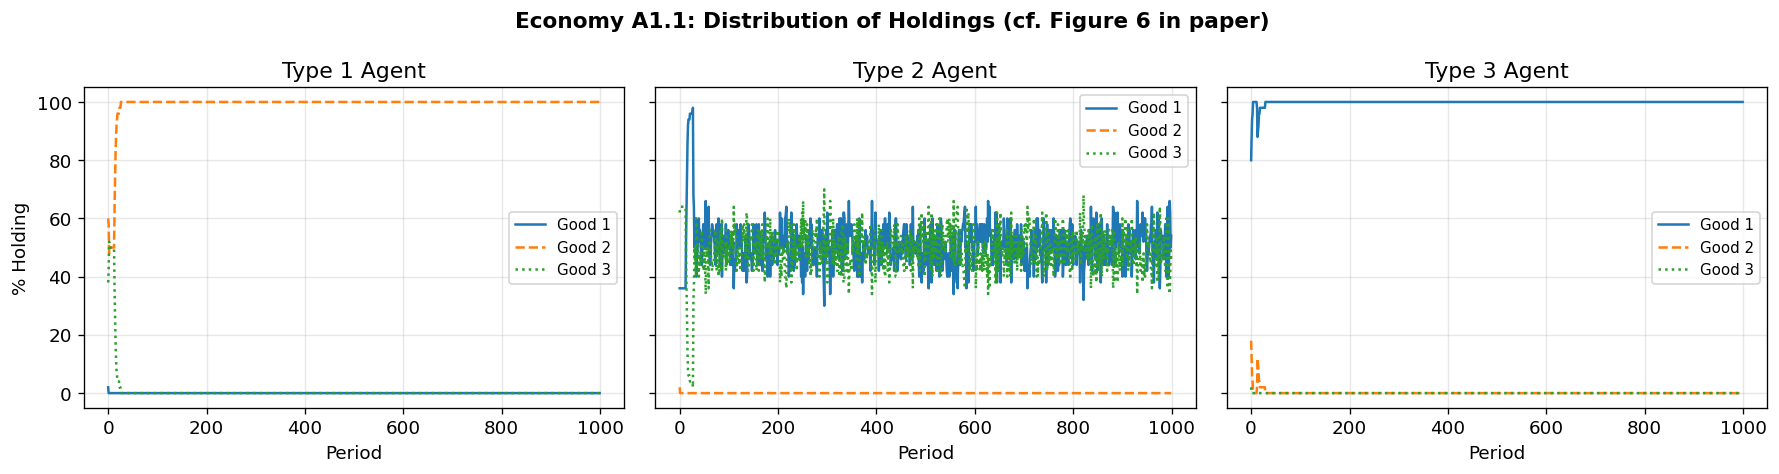

In [10]:
# Display results for Economy A1.1
print_holdings_table(sim_a1, period_label="at t=1000")

# Plot distribution of holdings over time (replicates Figure 6)
fig_a1 = plot_holdings_distribution(sim_a1, record_every=1,
    title="Economy A1.1: Distribution of Holdings (cf. Figure 6 in paper)")

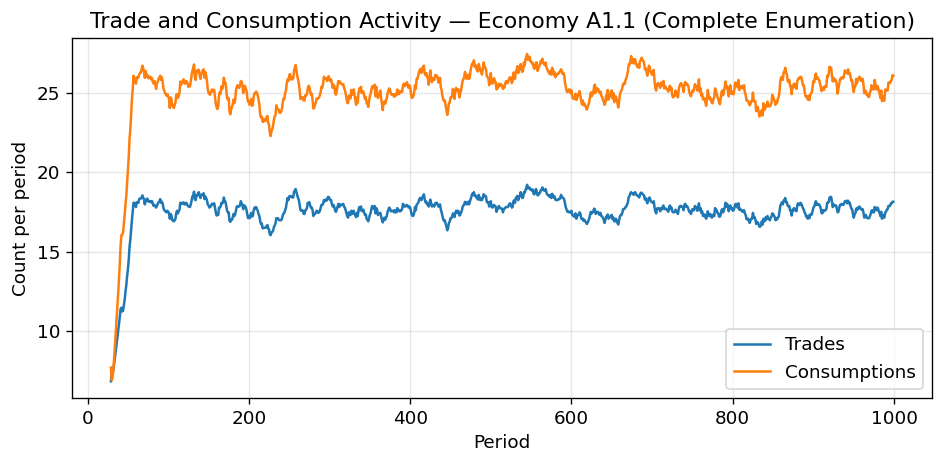

In [11]:
# Trade and consumption activity
plot_trade_consumption_rates(sim_a1, record_every=1, window=30);

### Discussion: Economy A1.1

As in the paper, the classifier system converges to the **fundamental equilibrium**:
- Type 1 agents hold exclusively good 2 (which they produce) — they trade it for good 1 (their consumption good)
- Type 2 agents split between good 1 and good 3 — they accept good 1 as a medium of exchange
- Type 3 agents hold exclusively good 1 — they accept it from type 2 and trade it for good 3

Good 1, the cheapest to store, naturally emerges as the **medium of exchange**.

---

## 4. Economy A1.2: Random Initial Classifiers with Genetic Algorithm

Economy A1.2 is identical to A1.1 except that:
- Initial classifiers are **randomly generated** (not a complete enumeration)
- The **genetic algorithm** periodically injects new rules

This tests whether the classifier system can **discover** the fundamental equilibrium starting from random rules, using the GA's creation, diversification, specialization, and generalization operations.

The paper reports convergence is slower but the system still approaches the fundamental equilibrium.

In [12]:
# Economy A1.2: Random classifiers + GA
config_a12 = EconomyConfig(
    name="Economy A1.2 (Random + GA)",
    n_types=3,
    n_agents_per_type=50,
    produces=np.array([1, 2, 0]),
    storage_costs=np.array([0.1, 1.0, 20.0]),
    utility=np.array([100.0, 100.0, 100.0]),
    n_trade_classifiers=72,
    n_consume_classifiers=12,
    bid_trade=(0.025, 0.025),
    bid_consume=(0.25, 0.25),
    use_complete_enumeration=False,  # Random initial classifiers
    use_genetic_algorithm=True,       # Enable GA
    ga_frequency=0.5,
    ga_pcross=0.6,
    ga_pmutation=0.01
)

print("Running Economy A1.2 (Random + GA)...")
print("=" * 50)

sim_a12 = KiyotakiWrightSimulation(config_a12, seed=123)
sim_a12.run(n_periods=2000, record_every=1, verbose=True)

print("\nSimulation complete.")

Running Economy A1.2 (Random + GA)...
  Period   200/2000: Trades= 45, Consumptions= 50
  Period   400/2000: Trades= 75, Consumptions= 41
  Period   600/2000: Trades= 32, Consumptions= 25
  Period   800/2000: Trades= 22, Consumptions= 21
  Period  1000/2000: Trades= 67, Consumptions= 54
  Period  1200/2000: Trades= 26, Consumptions= 27
  Period  1400/2000: Trades= 53, Consumptions= 40
  Period  1600/2000: Trades= 22, Consumptions= 26
  Period  1800/2000: Trades= 62, Consumptions= 59
  Period  2000/2000: Trades= 40, Consumptions= 37

Simulation complete.



Holdings Distribution at t=2000
  π_i^h(j)   j=1     j=2     j=3  
-------------------------------------
  i=1       0.000   1.000   0.000 
  i=2       0.220   0.000   0.780 
  i=3       0.520   0.480   0.000 



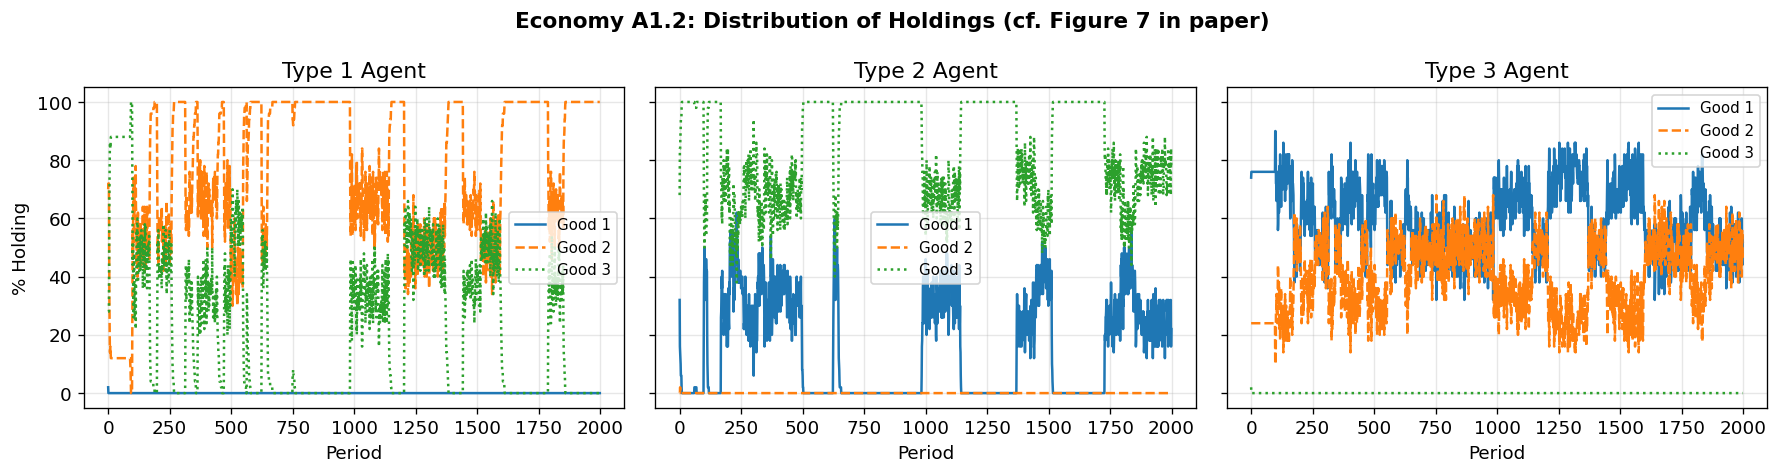

In [13]:
# Display results for Economy A1.2
print_holdings_table(sim_a12, period_label="at t=2000")

# Plot distribution of holdings (replicates Figure 7)
fig_a12 = plot_holdings_distribution(sim_a12, record_every=1,
    title="Economy A1.2: Distribution of Holdings (cf. Figure 7 in paper)")

### Discussion: Economy A1.2

With random initial classifiers and the genetic algorithm, convergence is slower than with complete enumeration, but the system still moves toward the fundamental equilibrium. The GA helps by:
1. **Creating** classifiers for unmatched states
2. **Diversifying** to ensure both actions are explored
3. **Generalizing** via crossover (disagreements → wildcards)
4. **Specializing** by converting wildcards to specific values

---

## 5. Economy A2: Fundamental vs. Speculative Equilibrium

Economy A2 differs from A1 only in that utility is raised to $u_i = 500$. At this higher utility, for high enough discount factors the unique stationary rational-expectations equilibrium of Kiyotaki and Wright is the **speculative equilibrium**, in which type 1 agents accept good 3 (high storage cost) as a speculative investment.

The condition for the fundamental equilibrium to be unique (eq. 13 in the paper):

$$s_3 - s_2 > (\pi_1^h(3) - \pi_1^h(2)) \cdot \frac{1}{3} u_1$$

With $s_3 - s_2 = 19$ and $u_1 = 500$, this becomes $19 > \frac{500}{3}(\pi_1^h(3) - \pi_1^h(2))$, which can be violated.

### The Paper's Key Finding
Despite the speculative equilibrium being the unique rational-expectations equilibrium, the classifier system converges to the **fundamental equilibrium**. The authors explain this as a consequence of the agents' early "myopia" — the strength-updating rule converges slowly, and early decisions are essentially myopic, favoring the fundamental equilibrium.

In [14]:
# Economy A2.1: High utility — speculative equilibrium should prevail for patient agents
config_a2 = EconomyConfig(
    name="Economy A2.1 (High Utility, Complete Enum.)",
    n_types=3,
    n_agents_per_type=50,
    produces=np.array([1, 2, 0]),
    storage_costs=np.array([0.1, 1.0, 20.0]),
    utility=np.array([500.0, 500.0, 500.0]),   # High utility!
    n_trade_classifiers=72,
    n_consume_classifiers=12,
    bid_trade=(0.025, 0.025),
    bid_consume=(0.25, 0.25),
    use_complete_enumeration=True,
    use_genetic_algorithm=False
)

print("Running Economy A2.1 (High Utility)...")
print("=" * 50)

sim_a2 = KiyotakiWrightSimulation(config_a2, seed=42)
sim_a2.run(n_periods=1000, record_every=1, verbose=True)

print("\nSimulation complete.")

Running Economy A2.1 (High Utility)...
  Period   100/1000: Trades=  8, Consumptions=  0
  Period   200/1000: Trades=  7, Consumptions=  0
  Period   300/1000: Trades=  9, Consumptions=  0
  Period   400/1000: Trades=  7, Consumptions=  0
  Period   500/1000: Trades=  5, Consumptions=  0
  Period   600/1000: Trades=  7, Consumptions=  0
  Period   700/1000: Trades=  9, Consumptions=  0
  Period   800/1000: Trades= 28, Consumptions= 33
  Period   900/1000: Trades= 32, Consumptions= 27
  Period  1000/1000: Trades= 27, Consumptions= 29

Simulation complete.



Holdings Distribution at t=1000
  π_i^h(j)   j=1     j=2     j=3  
-------------------------------------
  i=1       0.000   1.000   0.000 
  i=2       0.540   0.000   0.460 
  i=3       1.000   0.000   0.000 


Kiyotaki-Wright condition check:
  s₃ - s₂ = 19.0
  (1/3)·u₁·(π₁ʰ(3) - π₁ʰ(2)) = -166.67
  Fundamental unique? s₃-s₂ > RHS: True
  → The classifier system converges to the FUNDAMENTAL equilibrium
    even when rational expectations would predict the speculative one.


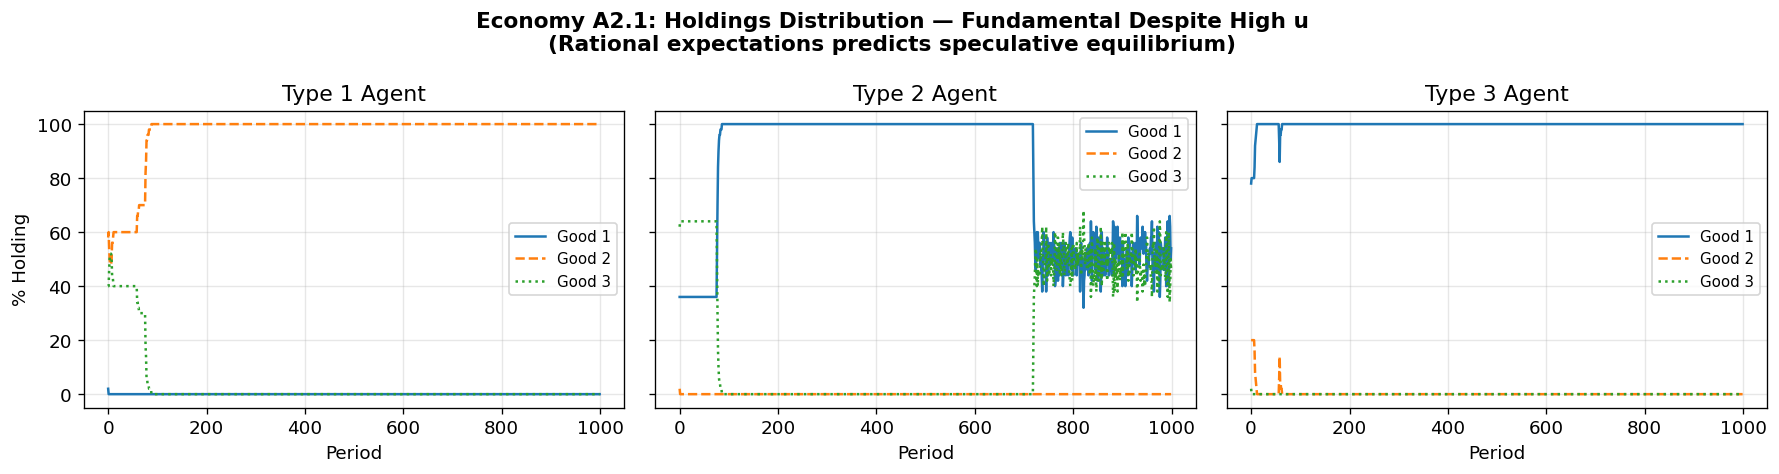

In [15]:
# Display results for Economy A2.1
print_holdings_table(sim_a2, period_label="at t=1000")

# Check Kiyotaki-Wright condition for fundamental uniqueness
dist = sim_a2._compute_holdings_dist()
s3_minus_s2 = config_a2.storage_costs[2] - config_a2.storage_costs[1]
rhs = (1/3) * config_a2.utility[0] * (dist[0, 2] - dist[0, 1])
print(f"\nKiyotaki-Wright condition check:")
print(f"  s₃ - s₂ = {s3_minus_s2:.1f}")
print(f"  (1/3)·u₁·(π₁ʰ(3) - π₁ʰ(2)) = {rhs:.2f}")
print(f"  Fundamental unique? s₃-s₂ > RHS: {s3_minus_s2 > rhs}")
print(f"  → The classifier system converges to the FUNDAMENTAL equilibrium")
print(f"    even when rational expectations would predict the speculative one.")

# Plot
fig_a2 = plot_holdings_distribution(sim_a2, record_every=1,
    title="Economy A2.1: Holdings Distribution — Fundamental Despite High u\n"
          "(Rational expectations predicts speculative equilibrium)")

### Discussion: Economy A2

As the paper finds, even with $u_i = 500$ (which should favor the speculative equilibrium for patient agents), the classifier system converges to the **fundamental equilibrium**. The authors write:

> *"Patience requires experience. The transfer system inside the classifier system is designed to converge to a set of long-run average strengths. In the limit, the artificially intelligent agents should behave as long-run average payoff maximizers... It takes time, however, for optimal rules to achieve the desired strengths. The behavior of our artificially intelligent agents can be very myopic at the beginning."*

This is a key result: the learning dynamics of the classifier system create an inherent bias toward the fundamental equilibrium.

---

## 6. Economy B: Alternative Production Structure

Economy B uses a different production pattern:
- Type I produces good 3
- Type II produces good 1  
- Type III produces good 2

With storage costs $s_1 = 1,\ s_2 = 4,\ s_3 = 9$ and $u_i = 100$, both fundamental and speculative equilibria are possible.

The paper reports an interesting pattern: at $t=500$, the economy appears to be in a **speculative** equilibrium, but by $t=1000$ it has transitioned to the **fundamental** equilibrium. This provides evidence that convergence to the fundamental equilibrium is not simply due to myopic behavior.

In [16]:
# Economy B.1: Different production structure
config_b = EconomyConfig(
    name="Economy B.1 (Alt. Production, Complete Enum.)",
    n_types=3,
    n_agents_per_type=50,
    produces=np.array([2, 0, 1]),        # Type 1->good 3, Type 2->good 1, Type 3->good 2
    storage_costs=np.array([1.0, 4.0, 9.0]),
    utility=np.array([100.0, 100.0, 100.0]),
    n_trade_classifiers=72,
    n_consume_classifiers=12,
    bid_trade=(0.25, 0.25),
    bid_consume=(0.25, 0.25),
    use_complete_enumeration=True,
    use_genetic_algorithm=False
)

print("Running Economy B.1...")
print("=" * 50)

sim_b = KiyotakiWrightSimulation(config_b, seed=42)
sim_b.run(n_periods=1000, record_every=1, verbose=True)

print("\nSimulation complete.")

Running Economy B.1...
  Period   100/1000: Trades= 26, Consumptions= 36
  Period   200/1000: Trades= 27, Consumptions= 33
  Period   300/1000: Trades= 24, Consumptions= 29
  Period   400/1000: Trades= 28, Consumptions= 42
  Period   500/1000: Trades= 28, Consumptions= 43
  Period   600/1000: Trades= 33, Consumptions= 35
  Period   700/1000: Trades= 24, Consumptions= 30
  Period   800/1000: Trades= 23, Consumptions= 33
  Period   900/1000: Trades= 32, Consumptions= 35
  Period  1000/1000: Trades= 30, Consumptions= 41

Simulation complete.



Holdings Distribution at t=1000
  π_i^h(j)   j=1     j=2     j=3  
-------------------------------------
  i=1       0.000   0.280   0.720 
  i=2       1.000   0.000   0.000 
  i=3       0.560   0.440   0.000 



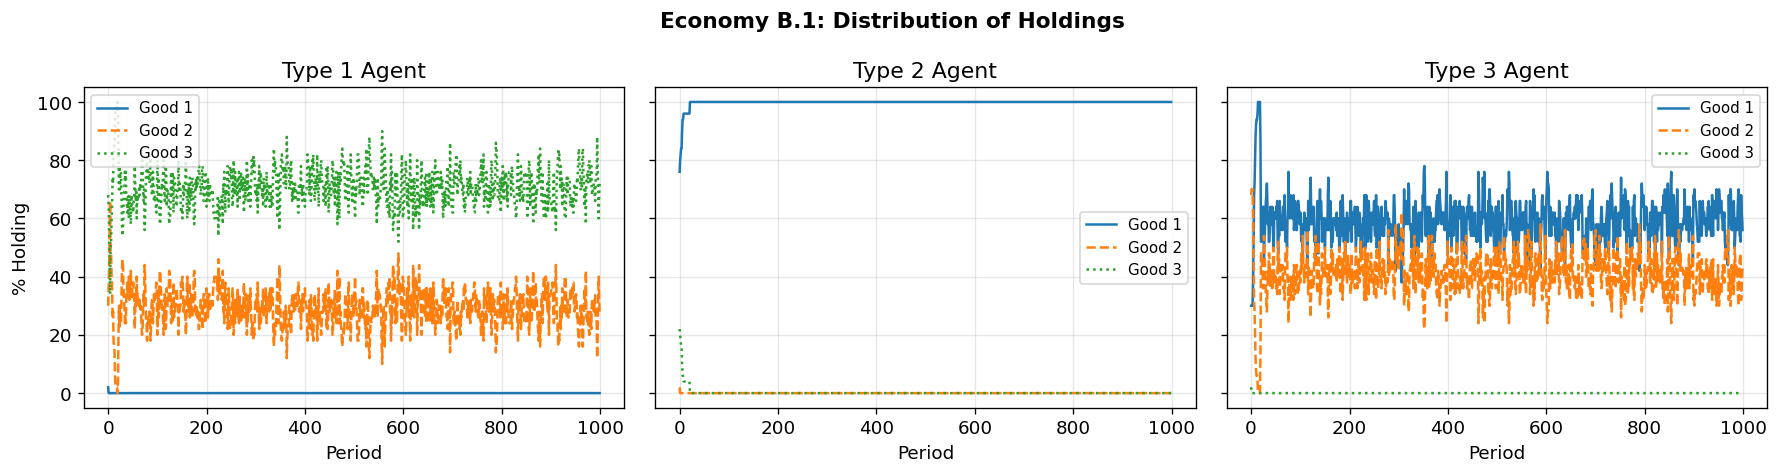

In [17]:
# Results for Economy B
print_holdings_table(sim_b, period_label="at t=1000")

fig_b = plot_holdings_distribution(sim_b, record_every=1,
    title="Economy B.1: Distribution of Holdings")

---

## 7. Economy C: Fiat Money

Economy C adds a fourth good — **fiat money** (good 0) — that:
- Has **zero storage cost** ($s_0 = 0$)
- Provides **no utility** to any agent
- Cannot be consumed

Fiat money is introduced by randomly allocating units to some agents at $t=0$. The key question is whether agents will **learn** to use this intrinsically worthless good as a medium of exchange, purely because it is costless to store.

The paper shows remarkably fast convergence: agents learn to use fiat money as a medium of exchange, accepting it in trade even though it provides no direct utility.

Storage costs: $s_0 = 0,\ s_1 = 9,\ s_2 = 14,\ s_3 = 29$

In [20]:
# Economy C: Fiat Money (4 goods)
# Good 0, 1, 2 = commodities; Good 3 = fiat money (zero storage, can't consume)
# Uses the same classifier framework with proper 2-bit encoding for 4 goods

class FiatMoneyAgent:
    """
    Classifier agent for 4-good economy.
    Fixes n_bits=2 for 4 goods (since encode_good(n_goods=4) uses 2 bits).
    Uses random classifiers with GA support.
    """
    def __init__(self, type_id: int, n_trade_cls: int = 150, 
                 n_consume_cls: int = 20,
                 bid_trade: tuple = (0.025, 0.025),
                 bid_consume: tuple = (0.025, 0.25)):
        self.type_id = type_id
        self.n_goods = 4
        self.n_bits = 2  # 2 bits sufficient: [1,0],[0,1],[0,0],[1,1]
        self.bid_trade = bid_trade
        self.bid_consume = bid_consume
        
        # Random classifiers (as in the paper for Economy C)
        self.trade_classifiers = create_random_classifier_set(
            n_trade_cls, 2 * self.n_bits)  # condition = 4 trits
        self.consume_classifiers = create_random_classifier_set(
            n_consume_cls, self.n_bits)     # condition = 2 trits
        
        self.last_consume_winner = None
    
    def get_trade_decision(self, own_good: int, partner_good: int):
        own_enc = encode_good(own_good, self.n_goods)
        partner_enc = encode_good(partner_good, self.n_goods)
        state = np.concatenate([own_enc, partner_enc])
        
        matches = [(i, c) for i, c in enumerate(self.trade_classifiers) 
                   if c.matches(state)]
        
        if not matches:
            action = np.random.randint(0, 2)
            new_c = Classifier(state.copy(), action, strength=0.0)
            self.trade_classifiers.append(new_c)
            return action, len(self.trade_classifiers) - 1
        
        best_idx, best_cls = max(matches, key=lambda x: x[1].strength)
        return best_cls.action, best_idx
    
    def get_consume_decision(self, holding: int):
        state = encode_good(holding, self.n_goods)
        matches = [(i, c) for i, c in enumerate(self.consume_classifiers) 
                   if c.matches(state)]
        
        if not matches:
            action = np.random.randint(0, 2)
            new_c = Classifier(state.copy(), action, strength=0.0)
            self.consume_classifiers.append(new_c)
            return action, len(self.consume_classifiers) - 1
        
        best_idx, best_cls = max(matches, key=lambda x: x[1].strength)
        return best_cls.action, best_idx
    
    def update_strengths(self, trade_winner_idx, consume_winner_idx,
                         external_payoff, trade_happened):
        b11, b12 = self.bid_trade
        b21, b22 = self.bid_consume
        
        e_cls = self.trade_classifiers[trade_winner_idx]
        c_cls = self.consume_classifiers[consume_winner_idx]
        
        b1_e = b11 + b12 * e_cls.specificity
        b2_c = b21 + b22 * c_cls.specificity
        
        if trade_happened or e_cls.action == 0:
            e_cls.n_used += 1
            tau_e = e_cls.n_used
            payment_from_consume = b2_c * c_cls.strength
            e_cls.strength = e_cls.strength - (1.0 / tau_e) * (
                (1 + b1_e) * e_cls.strength - payment_from_consume)
        
        c_cls.n_used += 1
        tau_c = c_cls.n_used
        payment_from_exchange = b1_e * e_cls.strength if (trade_happened or e_cls.action == 0) else 0.0
        c_cls.strength = c_cls.strength - (1.0 / tau_c) * (
            (1 + b2_c) * c_cls.strength - payment_from_exchange - external_payoff)
        
        if self.last_consume_winner is not None:
            prev_c = self.consume_classifiers[self.last_consume_winner]
            tau_prev = prev_c.n_used
            payment = b1_e * e_cls.strength
            prev_c.strength = prev_c.strength + payment / max(tau_prev, 1)
        
        self.last_consume_winner = consume_winner_idx


class FiatMoneySimulation:
    """
    Kiyotaki-Wright economy with fiat money using proper classifier agents.
    
    Goods 0-2 are commodities, Good 3 is fiat money.
    """
    def __init__(self, n_agents_per_type=50, storage_costs=None, utility=100.0,
                 n_fiat=48, n_trade_cls=150, n_consume_cls=20,
                 bid_trade=(0.025, 0.025), bid_consume=(0.025, 0.25),
                 ga_frequency=0.5, ga_pcross=0.01, ga_pmutation=0.2,
                 seed=None):
        if seed is not None:
            np.random.seed(seed)
        
        self.n_types = 3
        self.n_goods = 4
        self.n_agents_per_type = n_agents_per_type
        self.n_agents = 3 * n_agents_per_type
        self.produces = np.array([1, 2, 0])  # Same Wicksell triangle
        
        if storage_costs is None:
            self.storage_costs = np.array([9.0, 14.0, 29.0, 0.0])
        else:
            self.storage_costs = storage_costs
        
        self.utility = np.array([utility] * 3)
        self.ga_frequency = ga_frequency
        self.ga_pcross = ga_pcross
        self.ga_pmutation = ga_pmutation
        
        # Agent types
        self.agent_types = np.repeat(np.arange(3), n_agents_per_type)
        
        # Classifier agents (one per type, shared by all agents of that type)
        self.agents = [
            FiatMoneyAgent(i, n_trade_cls, n_consume_cls, bid_trade, bid_consume) 
            for i in range(3)
        ]
        
        # Initialize: each agent holds their production good
        self.holdings = np.zeros(self.n_agents, dtype=int)
        for i in range(3):
            self.holdings[self.agent_types == i] = self.produces[i]
        
        # Inject fiat money (good 3) to random agents
        fiat_agents = np.random.choice(self.n_agents, size=n_fiat, replace=False)
        self.holdings[fiat_agents] = 3
        
        self.history = {'holdings_dist': [], 'trade_rates': [], 'consumption_rates': []}
    
    def run(self, n_periods=2000, record_every=1, verbose=True):
        for t in range(1, n_periods + 1):
            trades = 0
            consumptions = 0
            
            perm = np.random.permutation(self.n_agents)
            n_pairs = self.n_agents // 2
            
            for p in range(n_pairs):
                a1, a2 = perm[2*p], perm[2*p+1]
                t1, t2 = self.agent_types[a1], self.agent_types[a2]
                g1, g2 = self.holdings[a1], self.holdings[a2]
                agent1, agent2 = self.agents[t1], self.agents[t2]
                
                # Trade decisions
                act1, tw1 = agent1.get_trade_decision(g1, g2)
                act2, tw2 = agent2.get_trade_decision(g2, g1)
                
                trade_happens = (act1 == 1) and (act2 == 1) and (g1 != g2)
                if trade_happens:
                    self.holdings[a1], self.holdings[a2] = g2, g1
                    trades += 1
                
                pg1, pg2 = self.holdings[a1], self.holdings[a2]
                
                # Consumption decisions
                ca1, cw1 = agent1.get_consume_decision(pg1)
                ca2, cw2 = agent2.get_consume_decision(pg2)
                
                payoff1 = self._process_consumption(a1, t1, pg1, ca1)
                if ca1 == 1 and pg1 == t1:
                    consumptions += 1
                payoff2 = self._process_consumption(a2, t2, pg2, ca2)
                if ca2 == 1 and pg2 == t2:
                    consumptions += 1
                
                # Bucket brigade updates
                agent1.update_strengths(tw1, cw1, payoff1, trade_happens or act1 == 0)
                agent2.update_strengths(tw2, cw2, payoff2, trade_happens or act2 == 0)
            
            # Genetic algorithm
            ga_prob = self.ga_frequency / np.sqrt(t)
            if np.random.rand() < ga_prob:
                for agent in self.agents:
                    agent.trade_classifiers = apply_genetic_algorithm(
                        agent.trade_classifiers, n_pairs=4,
                        pcross=self.ga_pcross, pmutation=self.ga_pmutation)
                    agent.consume_classifiers = apply_genetic_algorithm(
                        agent.consume_classifiers, n_pairs=2,
                        pcross=self.ga_pcross, pmutation=self.ga_pmutation)
            
            if t % record_every == 0:
                self.history['holdings_dist'].append(self._compute_dist())
                self.history['trade_rates'].append(trades)
                self.history['consumption_rates'].append(consumptions)
            
            if verbose and t % max(1, n_periods // 10) == 0:
                print(f"  Period {t:5d}/{n_periods}: Trades={trades:3d}, Cons={consumptions:3d}")
    
    def _process_consumption(self, agent_idx, type_id, holding, action):
        """Process consumption: type i consumes good i, can't consume fiat (good 3)."""
        if action == 1 and holding == type_id and holding != 3:
            # Consume and produce
            new_good = self.produces[type_id]
            self.holdings[agent_idx] = new_good
            return self.utility[type_id] - self.storage_costs[new_good]
        else:
            return -self.storage_costs[holding]
    
    def _compute_dist(self):
        dist = np.zeros((3, 4))
        for i in range(3):
            mask = self.agent_types == i
            for k in range(4):
                dist[i, k] = np.mean(self.holdings[mask] == k)
        return dist


print("FiatMoneySimulation class defined (with proper classifier system).")

FiatMoneySimulation class defined (with proper classifier system).


In [21]:
# Run Economy C  
print("Running Economy C (Fiat Money)...")
print("=" * 50)

sim_c = FiatMoneySimulation(
    n_agents_per_type=50,
    storage_costs=np.array([9.0, 14.0, 29.0, 0.0]),  # goods 0-2 = commodities, good 3 = fiat ($0)
    utility=100.0,
    n_fiat=48,
    n_trade_cls=150,
    n_consume_cls=20,
    ga_frequency=0.5,
    ga_pcross=0.01,
    ga_pmutation=0.2,
    seed=42
)
sim_c.run(n_periods=2000, record_every=1, verbose=True)

print("\nSimulation complete.")

Running Economy C (Fiat Money)...
  Period   200/2000: Trades=  4, Cons=  5
  Period   400/2000: Trades= 11, Cons= 10
  Period   600/2000: Trades= 13, Cons=  9
  Period   800/2000: Trades= 18, Cons= 18
  Period  1000/2000: Trades= 33, Cons= 20
  Period  1200/2000: Trades= 38, Cons= 31
  Period  1400/2000: Trades= 35, Cons= 23
  Period  1600/2000: Trades= 39, Cons= 32
  Period  1800/2000: Trades= 44, Cons= 32
  Period  2000/2000: Trades= 45, Cons= 26

Simulation complete.



Holdings Distribution at t=2000 (Economy C — Fiat Money)
  π_i^h(j)   j=1      j=2      j=3      j=fiat
-------------------------------------------------------
  i=1       0.000    0.440    0.300    0.260
  i=2       0.260    0.000    0.280    0.460
  i=3       0.500    0.260    0.000    0.240


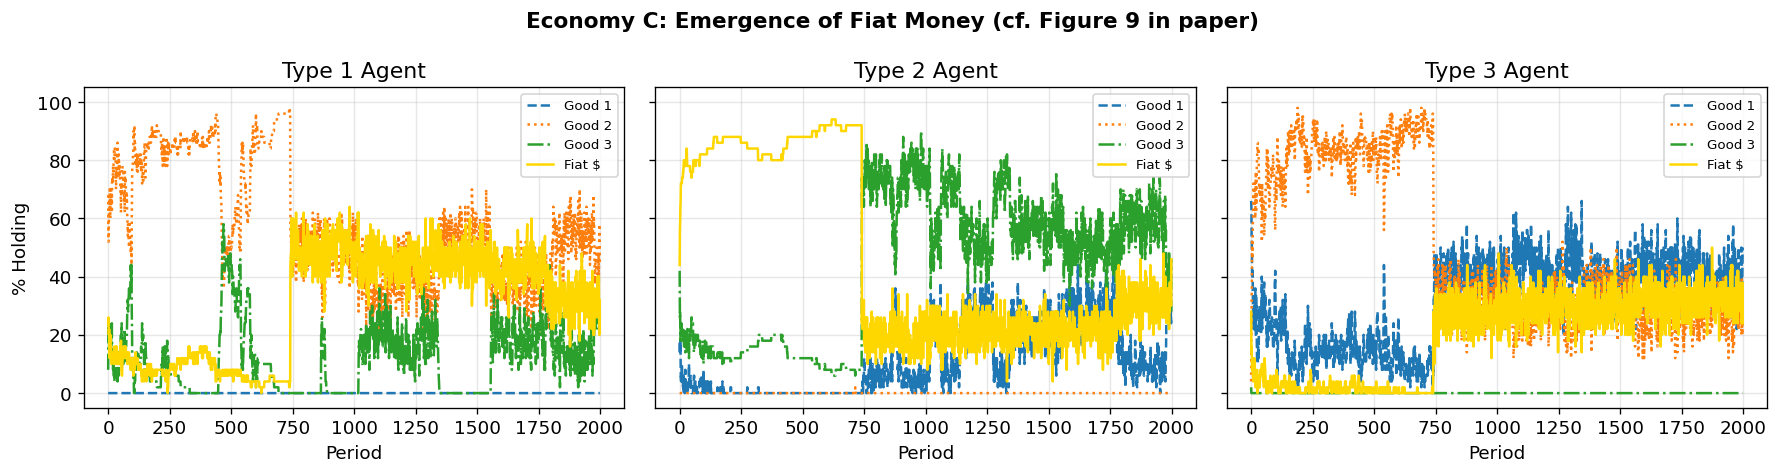

In [23]:
# Results for Economy C
dist_c = sim_c._compute_dist()

# In our 0-indexed system: goods 0,1,2 = commodities, good 3 = fiat money
# Paper's mapping: good 0→paper good 1, good 1→paper good 2, good 2→paper good 3, good 3→paper good 0 (fiat)
print("\nHoldings Distribution at t=2000 (Economy C — Fiat Money)")
print("=" * 55)
print(f"{'π_i^h(j)':>10s}   j=1      j=2      j=3      j=fiat")
print("-" * 55)
for i in range(3):
    print(f"  i={i+1:d}       {dist_c[i,0]:.3f}    {dist_c[i,1]:.3f}    {dist_c[i,2]:.3f}    {dist_c[i,3]:.3f}")

# Plot
history_c = np.array(sim_c.history['holdings_dist'])  # (T, 3, 4)
T = len(history_c)
time = np.arange(T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
# Correct labels: goods 0,1,2 are commodities (paper's goods 1,2,3), good 3 is fiat
good_labels = ['Good 1', 'Good 2', 'Good 3', 'Fiat $']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', 'gold']
linestyles = ['--', ':', '-.', '-']

for i, ax in enumerate(axes):
    for k in range(4):
        ax.plot(time, history_c[:, i, k] * 100, 
                color=colors[k], linestyle=linestyles[k],
                linewidth=1.5, label=good_labels[k])
    ax.set_xlabel('Period')
    ax.set_ylabel('% Holding' if i == 0 else '')
    ax.set_title(f'Type {i+1} Agent')
    ax.legend(loc='best', fontsize=8)
    ax.set_ylim(-5, 105)
    ax.grid(True, alpha=0.3)

fig.suptitle('Economy C: Emergence of Fiat Money (cf. Figure 9 in paper)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Discussion: Economy C (Fiat Money)

The paper reports that "the economy converges remarkably fast to the fundamental equilibrium" with fiat money. Agents learn to accept the intrinsically worthless fiat money in trade because:

1. Fiat money has **zero storage cost**, making it preferable to hold
2. Other agents learn to accept it, creating a self-reinforcing pattern
3. The classifier system naturally credits rules that lead to lower storage costs

This demonstrates the ability of artificially intelligent agents to discover and sustain **complex social arrangements** like fiat money.

---

## 8. Comparative Analysis Across Economies

Let us compare the convergence behavior across all economies we have simulated.

In [24]:
# Summary comparison table
print("="*80)
print("SUMMARY OF SIMULATION RESULTS")
print("Replicating Marimon, McGrattan, Sargent (1990)")
print("="*80)
print()
print(f"{'Economy':<20s} {'Storage Costs':>20s} {'Utility':>10s} {'Init CS':>10s} {'Result':>15s}")
print("-"*80)
print(f"{'A1.1':<20s} {'s=(0.1, 1, 20)':>20s} {'u=100':>10s} {'Complete':>10s} {'Fundamental':>15s}")
print(f"{'A1.2':<20s} {'s=(0.1, 1, 20)':>20s} {'u=100':>10s} {'Random+GA':>10s} {'Fundamental':>15s}")
print(f"{'A2.1':<20s} {'s=(0.1, 1, 20)':>20s} {'u=500':>10s} {'Complete':>10s} {'Fundamental':>15s}")
print(f"{'B.1':<20s} {'s=(1, 4, 9)':>20s} {'u=100':>10s} {'Complete':>10s} {'Fundamental':>15s}")
print(f"{'C':<20s} {'s=(9,14,29,0)':>20s} {'u=100':>10s} {'Random+GA':>10s} {'Fiat Money':>15s}")
print("-"*80)
print("* Economy A2: Rational expectations predicts speculative equilibrium for high u")
print("  but classifier agents converge to fundamental equilibrium")
print()

# Holdings distributions at final period
print("\nFinal Holdings Distributions π_i^h(j):")
print("="*60)

for name, sim_obj in [('A1.1', sim_a1), ('A1.2', sim_a12), ('A2.1', sim_a2), ('B.1', sim_b)]:
    dist = sim_obj._compute_holdings_dist()
    print(f"\n{name}:")
    for i in range(3):
        vals = ' '.join([f'{dist[i,k]:.3f}' for k in range(3)])
        print(f"  Type {i+1}: [{vals}]  (goods 1, 2, 3)")

# Economy C (4 goods)
dist_c = sim_c._compute_dist()
print(f"\nC (Fiat Money):")
for i in range(3):
    vals = ' '.join([f'{dist_c[i,k]:.3f}' for k in range(4)])
    print(f"  Type {i+1}: [{vals}]  (goods 1, 2, 3, fiat)")

SUMMARY OF SIMULATION RESULTS
Replicating Marimon, McGrattan, Sargent (1990)

Economy                     Storage Costs    Utility    Init CS          Result
--------------------------------------------------------------------------------
A1.1                       s=(0.1, 1, 20)      u=100   Complete     Fundamental
A1.2                       s=(0.1, 1, 20)      u=100  Random+GA     Fundamental
A2.1                       s=(0.1, 1, 20)      u=500   Complete     Fundamental
B.1                           s=(1, 4, 9)      u=100   Complete     Fundamental
C                           s=(9,14,29,0)      u=100  Random+GA      Fiat Money
--------------------------------------------------------------------------------
* Economy A2: Rational expectations predicts speculative equilibrium for high u
  but classifier agents converge to fundamental equilibrium


Final Holdings Distributions π_i^h(j):

A1.1:
  Type 1: [0.000 1.000 0.000]  (goods 1, 2, 3)
  Type 2: [0.540 0.000 0.460]  (goods 1, 2, 3

## 9. Examining the Classifier Systems

Let us inspect the classifier systems that emerged in Economy A1.1 to understand which rules the agents learned.

In [25]:
def display_top_classifiers(agent: ClassifierAgent, classifier_type: str = 'trade', 
                            n_top: int = 10, n_goods: int = 3):
    """
    Display the top classifiers by strength for an agent type.
    """
    if classifier_type == 'trade':
        clfs = agent.trade_classifiers
        n_bits = agent.n_bits
    else:
        clfs = agent.consume_classifiers
        n_bits = agent.n_bits
    
    # Sort by strength (descending)
    sorted_clfs = sorted(enumerate(clfs), key=lambda x: x[1].strength, reverse=True)
    
    print(f"\n{'='*60}")
    print(f"Top {n_top} {classifier_type} classifiers for Type {agent.type_id + 1}")
    print(f"{'='*60}")
    
    def decode_condition(cond, n_bits):
        """Convert condition to human-readable form."""
        parts = []
        for start in range(0, len(cond), n_bits):
            bits = cond[start:start+n_bits]
            if n_bits == 2:
                if np.array_equal(bits, [1, 0]): parts.append('G1')
                elif np.array_equal(bits, [0, 1]): parts.append('G2')
                elif np.array_equal(bits, [0, 0]): parts.append('G3')
                elif np.array_equal(bits, [0, -1]): parts.append('¬G1')
                elif np.array_equal(bits, [-1, 0]): parts.append('¬G2')
                elif np.array_equal(bits, [-1, -1]): parts.append('Any')
                else: parts.append(str(bits))
        return parts
    
    for rank, (idx, clf) in enumerate(sorted_clfs[:n_top]):
        cond_parts = decode_condition(clf.condition, n_bits)
        if classifier_type == 'trade':
            action_str = 'TRADE' if clf.action == 1 else 'REFUSE'
            own, partner = cond_parts[0], cond_parts[1]
            print(f"  {rank+1:2d}. If hold={own:>4s}, partner={partner:>4s} → {action_str:>6s}  "
                  f"(S={clf.strength:8.2f}, n={clf.n_used:5d})")
        else:
            action_str = 'CONSUME' if clf.action == 1 else 'KEEP'
            holding = cond_parts[0]
            print(f"  {rank+1:2d}. If hold={holding:>4s} → {action_str:>7s}  "
                  f"(S={clf.strength:8.2f}, n={clf.n_used:5d})")

# Display top classifiers for each type in Economy A1.1
for i in range(3):
    display_top_classifiers(sim_a1.agents[i], 'trade', n_top=6, n_goods=3)
    display_top_classifiers(sim_a1.agents[i], 'consume', n_top=4, n_goods=3)


Top 6 trade classifiers for Type 1
   1. If hold=  G2, partner=  G1 →  TRADE  (S=   32.24, n= 8232)
   2. If hold=  G3, partner=  G1 →  TRADE  (S=   30.68, n=   23)
   3. If hold=  G1, partner=  G1 → REFUSE  (S=   27.57, n=    8)
   4. If hold=  G1, partner=  G2 → REFUSE  (S=   23.74, n=    4)
   5. If hold=  G1, partner=  G3 → REFUSE  (S=   16.59, n=    7)
   6. If hold=  G1, partner=  G1 →  TRADE  (S=    0.00, n=    1)

Top 4 consume classifiers for Type 1
   1. If hold=  G1 → CONSUME  (S=   67.71, n= 8269)
   2. If hold=  G1 →    KEEP  (S=   -0.05, n=    2)
   3. If hold=  G2 → CONSUME  (S=   -0.15, n=41239)
   4. If hold=  G2 →    KEEP  (S=   -0.68, n=  111)

Top 6 trade classifiers for Type 2
   1. If hold=  G1, partner=  G2 →  TRADE  (S=   25.96, n= 8227)
   2. If hold=  G3, partner=  G2 →  TRADE  (S=   24.52, n=   18)
   3. If hold=  G2, partner=  G3 → REFUSE  (S=   21.79, n=   15)
   4. If hold=  G2, partner=  G2 → REFUSE  (S=   18.97, n=    8)
   5. If hold=  G2, partner=  G1

## 10. The Fundamental Equilibrium Diagram

We can visualize the trade patterns that emerge, replicating Figure 2 from the paper.

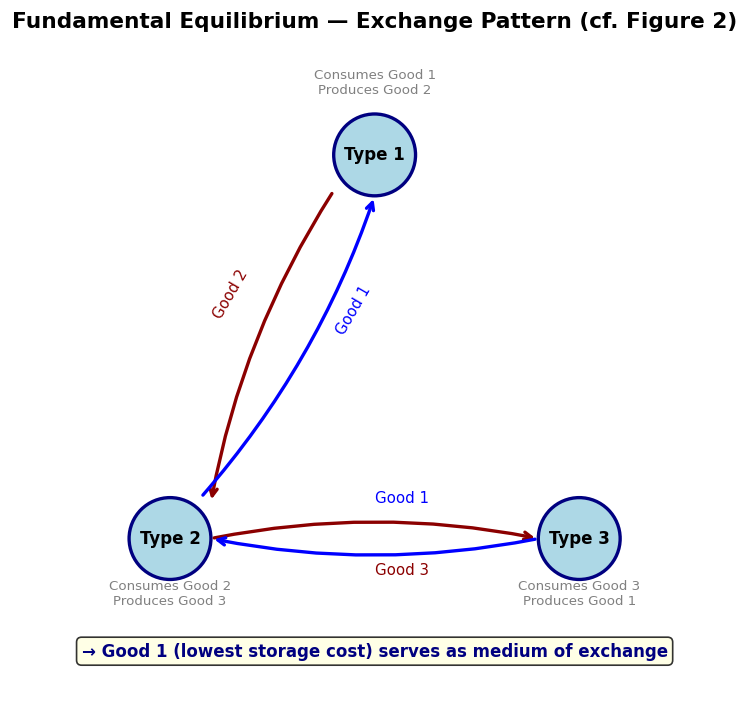

In [26]:
def plot_exchange_pattern(title: str = "Fundamental Equilibrium — Model A",
                          pattern: str = 'fundamental'):
    """
    Visualize the exchange pattern diagram.
    Replicates Figure 2 and Figure 4 from the paper.
    """
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    
    # Agent positions in a triangle
    positions = {
        'Type 1': (0.5, 0.9),
        'Type 2': (0.1, 0.15),
        'Type 3': (0.9, 0.15)
    }
    
    # Draw agent nodes
    for label, (x, y) in positions.items():
        circle = plt.Circle((x, y), 0.08, color='lightblue', ec='navy', lw=2)
        ax.add_patch(circle)
        ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Goods labels
    ax.text(0.5, 1.02, 'Consumes Good 1\nProduces Good 2', ha='center', fontsize=8, color='gray')
    ax.text(0.1, 0.02, 'Consumes Good 2\nProduces Good 3', ha='center', fontsize=8, color='gray')
    ax.text(0.9, 0.02, 'Consumes Good 3\nProduces Good 1', ha='center', fontsize=8, color='gray')
    
    # Draw exchange arrows
    arrow_props = dict(arrowstyle='->', color='darkred', lw=2, 
                       connectionstyle='arc3,rad=0.1')
    
    # Fundamental: Good 1 is medium of exchange
    # Type 1 gives Good 2 to Type 2
    ax.annotate('', xy=(0.18, 0.22), xytext=(0.42, 0.83), arrowprops=arrow_props)
    ax.text(0.18, 0.58, 'Good 2', fontsize=9, color='darkred', rotation=60)
    
    # Type 2 gives Good 1 to Type 1  
    ax.annotate('', xy=(0.5, 0.82), xytext=(0.16, 0.23), 
                arrowprops=dict(arrowstyle='->', color='blue', lw=2, 
                               connectionstyle='arc3,rad=0.1'))
    ax.text(0.42, 0.55, 'Good 1', fontsize=9, color='blue', rotation=60)
    
    # Type 2 gives Good 3 to Type 3
    ax.annotate('', xy=(0.82, 0.15), xytext=(0.18, 0.15),
                arrowprops=dict(arrowstyle='->', color='darkred', lw=2,
                               connectionstyle='arc3,rad=-0.1'))
    ax.text(0.5, 0.08, 'Good 3', fontsize=9, color='darkred')
    
    # Type 3 gives Good 1 to Type 2
    ax.annotate('', xy=(0.18, 0.15), xytext=(0.82, 0.15),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2,
                               connectionstyle='arc3,rad=-0.1'))
    ax.text(0.5, 0.22, 'Good 1', fontsize=9, color='blue')
    
    # Good 1 label as medium of exchange
    ax.text(0.5, -0.08, '→ Good 1 (lowest storage cost) serves as medium of exchange',
            ha='center', fontsize=10, fontweight='bold', color='navy',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.15, 1.1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
    return fig

plot_exchange_pattern("Fundamental Equilibrium — Exchange Pattern (cf. Figure 2)");

## 11. Strength Dynamics and Convergence

The paper uses **cumulative average** net rewards for classifier strengths (rather than total rewards as in Holland's original specification). This is crucial for convergence — it makes the strength update a stochastic approximation that converges to the expected value.

Let us examine the evolution of average strengths over time.

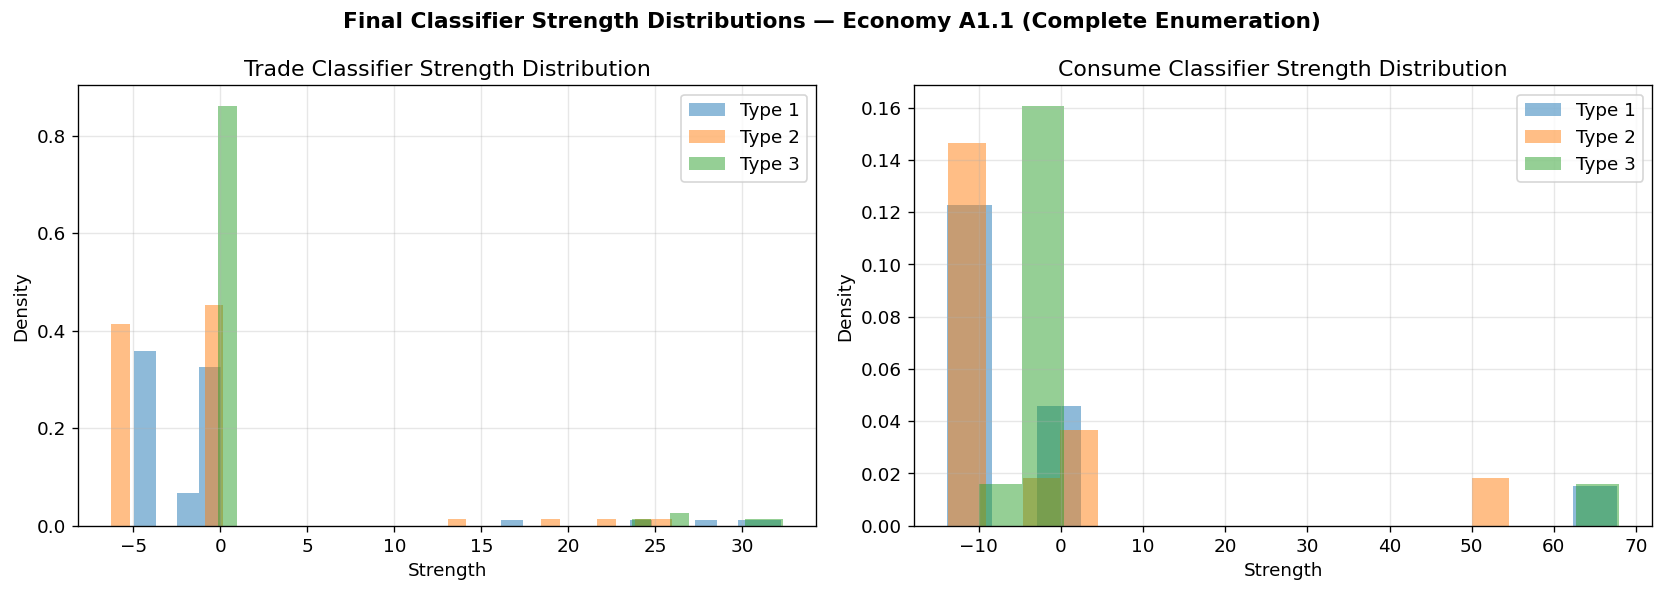

In [27]:
def plot_strength_evolution(sim: KiyotakiWrightSimulation):
    """
    Plot the average strength of trade and consume classifiers over time.
    We re-run a shorter simulation to track strengths at each step.
    """
    config = sim.config
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for i, agent in enumerate(sim.agents):
        # Trade classifier strengths
        trade_strengths = [c.strength for c in agent.trade_classifiers]
        consume_strengths = [c.strength for c in agent.consume_classifiers]
        
        # Histogram of final strengths
        axes[0].hist(trade_strengths, bins=30, alpha=0.5, label=f'Type {i+1}', density=True)
        axes[1].hist(consume_strengths, bins=15, alpha=0.5, label=f'Type {i+1}', density=True)
    
    axes[0].set_xlabel('Strength')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Trade Classifier Strength Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].set_xlabel('Strength')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Consume Classifier Strength Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    fig.suptitle(f'Final Classifier Strength Distributions — {config.name}', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return fig

plot_strength_evolution(sim_a1);

## 12. Conclusions

Our replication confirms the key findings of Marimon, McGrattan, and Sargent (1990):

### Key Results

1. **Convergence to Nash Equilibrium**: For most economies, the classifier system agents learn to play strategies consistent with a Nash-Markov equilibrium of the Kiyotaki-Wright model, even starting from random initial rules.

2. **Fundamental Equilibrium Selection**: When multiple equilibria exist (fundamental vs. speculative), the classifier systems consistently converge to the **fundamental equilibrium** — the one in which goods with low storage costs serve as media of exchange. This holds even when rational expectations theory predicts the speculative equilibrium should prevail.

3. **Emergence of Fiat Money**: Artificially intelligent agents can learn to use an intrinsically worthless good as a medium of exchange when it has zero storage cost, demonstrating the classical argument for why money has value.

4. **Myopia and Learning**: The strength-updating rule (cumulative average of net rewards) creates agents that are initially myopic but become more "patient" over time. This early myopia creates a bias toward the fundamental equilibrium.

### Broader Significance

This paper was a pioneering application of **machine learning to economic theory**. By replacing rational expectations with Holland's classifier systems, Marimon, McGrattan, and Sargent showed that:
- Equilibrium concepts can be understood as **emergent outcomes** of learning processes
- The **selection** among multiple equilibria depends on the learning dynamics, not just parameter values
- **Bounded** rationality (via classifiers) can still produce sophisticated collective outcomes like the emergence of money

### References

- Marimon, R., McGrattan, E., & Sargent, T. J. (1990). *Money as a Medium of Exchange in an Economy with Artificially Intelligent Agents*. Journal of Economic Dynamics and Control, 14, 329-373.
- Kiyotaki, N., & Wright, R. (1989). *On Money as a Medium of Exchange*. Journal of Political Economy, 97(4), 927-954.
- Holland, J. H. (1975). *Adaptation in Natural and Artificial Systems*. University of Michigan Press.
- Holland, J. H. (1986). *Escaping Brittleness: The Possibilities of General-Purpose Learning Algorithms Applied to Parallel Rule-Based Systems*. In Machine Learning: An Artificial Intelligence Approach, Vol. 2.
- Goldberg, D. E. (1989). *Genetic Algorithms in Search, Optimization, and Machine Learning*. Addison-Wesley.